# Notebook 06 — Documentation Technique du Pipeline Thumalien

**Objectif** : ce notebook constitue la documentation technique autonome du pipeline de détection de désinformation bilingue (FR/EN) développé dans le cadre du projet Thumalien. Il est conçu pour être lu indépendamment des autres notebooks et fournit une analyse critique complète du système, sa roadmap d'évolution, son plan de continuité d'activité et son bilan environnemental.

**Version du pipeline** : V1.5 (TF-IDF + LogReg bilingue + features émotionnelles PyTorch)  
**Datasets** : ISOT Fake News (44 898 articles EN) + Kaggle FrenchFakeNewsDetector (9 494 articles FR) + Emotion datasets bilingues (25 800 textes FR+EN, 7 classes)  
**Dernière mise à jour** : février 2026

---
## 1. Analyse critique des limites du pipeline

Tout système de détection automatique de désinformation comporte des limites intrinsèques qu'il est essentiel d'identifier et de quantifier pour évaluer la portée réelle des résultats obtenus. Cette section présente une analyse honnête des six principales limitations du pipeline Thumalien dans sa version actuelle.

### 1.1. Gap de domaine entre entraînement et inférence

Le pipeline est entraîné sur des **articles de presse** (ISOT : médiane 359 mots en anglais, Kaggle FR : médiane 39 mots en français) mais appliqué en production sur des **micro-posts Bluesky** dont la longueur médiane avoisine les 20 mots. Ce décalage de domaine (*domain shift*) affecte le système à plusieurs niveaux.

En premier lieu, le vocabulaire TF-IDF de 30 000 n-grams a été construit à partir d'articles structurés, avec des phrases complètes, des transitions logiques et un registre journalistique. Les posts Bluesky emploient un registre oral, des abréviations, du langage SMS et des références culturelles absentes du corpus d'entraînement. En conséquence, une proportion significative des tokens d'un post Bluesky peut être hors vocabulaire (*out-of-vocabulary*), réduisant la matrice TF-IDF à un vecteur creux peu informatif.

En second lieu, les 12 features linguistiques (ratio de majuscules, densité de ponctuation, score de sensationnalisme) ont été calibrées sur des articles longs. Leur distribution diffère sensiblement sur des textes de 20 mots : un seul point d'exclamation dans un post court produit une densité de ponctuation bien plus élevée que dans un article de 400 mots, ce qui peut biaiser la prédiction.

Le sanity check du notebook 05 illustre cette limite : sur 6 phrases FR construites manuellement, le modèle commet 2 erreurs, précisément sur des textes courts dont le style s'écarte du corpus d'entraînement.

### 1.2. Déséquilibre initial du dataset et correction apportée

La version initiale du pipeline (V0) reposait sur un déséquilibre massif : 44 898 articles anglais contre seulement 200 articles français synthétiques, générés artificiellement pour couvrir les thématiques classiques de désinformation francophone. Avec un oversampling x15, ces 200 textes étaient dupliqués pour atteindre 3 000 occurrences, soit 6 % du dataset total. Cette approche posait deux problèmes majeurs.

D'une part, le modèle voyait 15 fois chaque texte FR identique, ce qui conduisait à un sur-apprentissage sévère : le F1 de 100 % sur le holdout FR dans la V0 reflétait la mémorisation des textes plutôt qu'une réelle capacité de généralisation. D'autre part, 200 articles synthétiques ne couvraient qu'un sous-ensemble étroit de la diversité linguistique et thématique du français.

La correction apportée (intégration du Kaggle FrenchFakeNewsDetector, 9 494 articles réels dont 7 250 après filtrage des textes < 20 mots) transforme le volet français du pipeline. L'oversampling est réduit à x3, le ratio FR/EN passe de 6 % à 33 %, et les performances FR reflètent désormais une capacité de généralisation réelle (F1 de 0.98 sur un holdout non vu pendant l'entraînement).

### 1.3. Biais TF-IDF monolingue de la V1

Le vectoriseur TF-IDF construit un espace vectoriel unique pour les deux langues. En V0, avec `strip_accents='unicode'`, les accents français étaient supprimés, éliminant des distinctions sémantiques fondamentales : « ou » (conjonction) vs « où » (pronom relatif), « a » (verbe) vs « à » (préposition). Cette normalisation, adaptée à l'anglais, détruisait un signal discriminant en français.

La correction (passage à `strip_accents=None` en mode bilingue) préserve désormais ces distinctions. Cependant, le TF-IDF reste un modèle *bag-of-words* qui ignore l'ordre des mots et la syntaxe. Pour un pipeline bilingue, cette limitation est amplifiée : les n-grams français et anglais coexistent dans le même espace vectoriel sans aucune notion de langue, ce qui peut créer des interférences entre les deux vocabulaires sur les mots partagés (« information », « communication », « situation »).

### 1.4. Absence de ground truth pour les posts Bluesky

Le pipeline infère un label (VRAI/FAKE) et un score de crédibilité pour chaque post Bluesky collecté, mais **aucune vérification humaine** ne valide ces prédictions. Il n'existe pas de dataset labellisé de posts Bluesky en français ni en anglais pour le domaine de la désinformation.

En conséquence, les métriques de performance (F1, accuracy, ROC-AUC) sont calculées exclusivement sur les données d'entraînement (ISOT + Kaggle FR) via cross-validation et holdout. Ces métriques ne garantissent pas la performance en production sur des données Bluesky dont la distribution diffère significativement. Le score de crédibilité affiché au utilisateur doit être interprété comme un **indicateur probabiliste**, et non comme une vérité établie.

Cette limite est structurelle pour tout projet de détection de désinformation en temps réel : la vérification factuelle reste un processus humain, et le modèle ne peut que signaler des textes *statistiquement similaires* aux articles de désinformation du corpus d'entraînement.

### 1.5. Limite de l'oversampling : répétition des textes FR

Même réduit à x3, l'oversampling implique que les 7 250 articles FR uniques du Kaggle FrenchFakeNewsDetector sont vus 3 fois chacun par le modèle pendant l'entraînement. La cross-validation stratifiée atténue ce risque en s'assurant que les folds de test ne contiennent pas de doublons vus en entraînement, mais la matrice TF-IDF est construite sur l'ensemble (incluant les doublons), ce qui gonfle artificiellement les fréquences de termes français.

L'étude d'ablation du notebook 05 (condition 6) compare l'oversampling x3 avec une alternative sans duplication (class_weight='balanced'). Les résultats montrent que l'oversampling améliore le F1 FR car il agit à deux niveaux (représentation TF-IDF + classification), là où class_weight n'agit que sur le classifieur. Néanmoins, la V2 du pipeline (sentence-transformers) éliminera ce compromis en utilisant des embeddings pré-entraînés indépendants du volume d'entraînement.

### 1.6. Dépendance à langdetect pour le routage linguistique

Le routage linguistique du pipeline repose sur la bibliothèque `langdetect` pour identifier si un texte est en français, en anglais ou dans une autre langue. Cette bibliothèque utilise des profils de fréquences de caractères n-grams et fonctionne correctement sur des textes d'au moins 50 caractères.

Sur les posts Bluesky courts (< 30 mots), la détection de langue devient instable. Les textes mixtes (code-switching FR/EN courant sur les réseaux sociaux), les noms propres anglais dans un contexte français, ou les textes très courts (« Incroyable ! ») peuvent être mal routés. Une erreur de routage linguistique n'empêche pas la prédiction (le modèle est bilingue), mais elle affecte la pondération des features et le log d'analyse affiché à l'utilisateur.

La mitigation actuelle consiste à tronquer le texte à 500 caractères pour la détection (évitant les faux positifs sur les longues URL) et à utiliser un fallback vers l'anglais en cas d'erreur. Une amélioration envisagée est l'utilisation de `fasttext` (modèle `lid.176.bin`) qui offre de meilleures performances sur les textes courts.

---
## 2. Gouvernance technique et roadmap d'évolution

Le pipeline Thumalien suit une trajectoire d'évolution incrémentale, chaque version apportant un gain de capacité tout en restant compatible avec l'infrastructure existante (Docker Compose, MongoDB, collecte Bluesky). Cette section décrit les quatre jalons planifiés et les critères objectifs de transition entre chaque version.

### 2.1. V1 — Version actuelle (TF-IDF + LogReg bilingue)

La V1 constitue le socle fonctionnel du pipeline. Elle combine un vectoriseur TF-IDF de 30 000 features (uni/bi/tri-grams, sublinear TF, accents préservés en mode bilingue) avec 12 features linguistiques extraites manuellement (ratio de majuscules, densité de ponctuation, score de sensationnalisme, diversité lexicale, etc.). Le classifieur est une régression logistique avec `class_weight='balanced'` et pondération par langue via `sample_weight`.

**Données** : ISOT Fake News (44 898 articles EN après nettoyage du biais Reuters) + Kaggle FrenchFakeNewsDetector (7 250 articles FR après filtrage, oversampling x3 → 21 750). Total : ~65 500 articles.

**Performances mesurées** (notebook 05, ablation study) :

| Condition | F1 EN | F1 FR |
|---|---|---|
| EN-only → EN holdout | 0.9874 | — |
| EN-only → FR holdout | — | 0.5375 |
| FR-only → FR holdout | — | 0.9557 |
| Bilingue → EN holdout | 0.9842 | — |
| Bilingue → FR holdout | — | 0.9807 |

**Forces** : interprétabilité (coefficients LogReg), rapidité d'entraînement (< 2 min sur CPU), empreinte carbone négligeable (< 0.02 g CO2), pipeline de nettoyage robuste (suppression biais Reuters).

**Faiblesses** : modèle bag-of-words (pas de contexte), gap de domaine articles/Bluesky, oversampling FR.

### 2.2. V1.5 — Version actuelle : features émotionnelles intégrées

La V1.5 enrichit le vecteur de features en intégrant les prédictions du modèle d'analyse émotionnelle bilingue (MLP PyTorch, notebook 02). Ce modèle, entraîné sur 25 800 textes FR+EN fusionnés avec mapping de labels (love→joie, 7 classes : colère, dégoût, joie, neutre, peur, surprise, tristesse), produit un vecteur de 7 probabilités par texte.

**Architecture** : stacking à deux niveaux. Le premier niveau extrait les probabilités émotionnelles (7 classes) via le MLP PyTorch (`EmotionFeatureExtractor`), qui sont concaténées aux features TF-IDF + linguistiques existantes. Le vecteur de features passe de TF-IDF(30K) + 12 linguistiques à TF-IDF(30K) + 12 linguistiques + 7 émotionnelles = **30 019 features**. Le second niveau (LogReg bilingue) prend cette représentation enrichie en entrée.

**Modèle émotionnel** :
- Framework : PyTorch (migration depuis TensorFlow, incompatible Python 3.13)
- Architecture : Embedding(25K, 64) → GlobalAveragePooling → Dense(48) → Dense(24) → Dense(7, softmax)
- F1 macro (test bilingue) : 0.66 — seuil Phase 2 (F1 > 0.50) atteint
- Limites : les classes `degout` et `neutre` sont entraînées uniquement sur données FR

**Critère de transition V1 → V1.5** : le modèle émotionnel devait atteindre un F1 macro > 0.50 sur son propre jeu de test avant intégration. Avec F1 = 0.66, le critère est satisfait. L'ablation study (notebook 05, condition 7) mesure le delta F1 apporté par les features émotionnelles sur la détection de fake news.

### 2.3. V2 — Sentence-transformers multilingue (planifiée)

La V2 remplace le TF-IDF par des embeddings denses produits par un modèle de type `paraphrase-multilingual-MiniLM-L12-v2` (384 dimensions, 12 couches, pré-entraîné sur 50+ langues). Ce modèle encode la sémantique des phrases indépendamment de la langue, éliminant d'un coup le problème d'interférence FR/EN dans l'espace vectoriel et le besoin d'oversampling.

**Avantages attendus** : meilleure généralisation sur les textes courts (le modèle a été pré-entraîné sur des paires de phrases, y compris courtes), représentation sémantique (vs lexicale), transfert multilingue natif.

**Critère de transition V1.5 → V2** : F1 FR du modèle bilingue actuel < 0.85 sur un jeu de test de posts Bluesky labellisés manuellement (indicateur que le TF-IDF atteint ses limites sur le domaine cible). Le passage à V2 nécessite également la disponibilité d'un GPU pour l'entraînement (fine-tuning) ou l'utilisation d'embeddings figés.

### 2.4. V3 — Fine-tuning CamemBERT/RoBERTa bilingue (cible long terme)

La V3 représente l'objectif final : un modèle transformer bilingue fine-tuné spécifiquement sur la détection de désinformation. Deux architectures candidates : CamemBERT (BERT français pré-entraîné sur le corpus OSCAR) pour le volet FR, et RoBERTa-base pour le volet EN, combinés via un classifieur de tête partagé.

**Prérequis** : cette version nécessite (1) un volume significatif de posts Bluesky labellisés manuellement (minimum 2 000, idéalement 5 000+), collectés via une campagne de crowdsourcing ou d'annotation experte, et (2) un GPU pour le fine-tuning (estimé à 2-4h sur un T4).

**Critère de transition V2 → V3** : disponibilité d'au moins 2 000 posts Bluesky labellisés avec un accord inter-annotateurs (kappa de Cohen) > 0.7.

### 2.5. Architecture cible et flux de données

```
                        ┌─────────────────────────────────┐
                        │     Collecte Bluesky (AT Proto)  │
                        │     ~500 posts/jour FR+EN        │
                        └──────────────┬──────────────────┘
                                       │
                                       ▼
                        ┌─────────────────────────────────┐
                        │     MongoDB (raw_posts)          │
                        │     Stockage brut + métadonnées  │
                        └──────────────┬──────────────────┘
                                       │
                     ┌─────────────────┼─────────────────────┐
                     ▼                 ▼                     ▼
              ┌───────────┐     ┌──────────┐          ┌───────────┐
              │ langdetect│     │ TF-IDF   │          │ Emotions  │
              │ FR/EN/??  │     │ 30K feat.│          │ MLP PyTorch│
              └─────┬─────┘     └────┬─────┘          │ 7 probas  │
                    │                │                └─────┬─────┘
                    │                │                      │
                    │          ┌─────┴─────┐               │
                    │          │ Features  │               │
                    │          │ ling.(12) │               │
                    │          └─────┬─────┘               │
                    │                │                      │
                    │                ▼                      │
                    │         ┌─────────────┐              │
                    │         │ hstack(     │◄─────────────┘
                    │         │  TF-IDF,    │
                    │         │  ling.(12), │
                    │         │  emot.(7)   │
                    │         │ ) = 30 019  │
                    │         └──────┬──────┘
                    │                │
                    │                ▼
                    │         ┌─────────────┐
                    │         │ LogReg      │
                    │         │ calibré     │
                    │         │ bilingue    │
                    │         └──────┬──────┘
                    │                │
                    ▼                ▼
              ┌──────────────────────────────┐
              │  Prédiction :                 │
              │  - label (VRAI/FAKE)          │
              │  - score crédibilité (0-1)    │
              │  - langue détectée            │
              │  - log d'analyse              │
              └──────────────┬───────────────┘
                             │
                             ▼
              ┌──────────────────────────────┐
              │  MongoDB (enriched_posts)     │
              │  + Dashboard Streamlit        │
              └──────────────────────────────┘
```

Ce schéma illustre le flux de données de la V1.5 actuelle. Le bloc Emotions (MLP PyTorch) produit 7 probabilités qui sont concaténées aux features TF-IDF et linguistiques. La V2 remplacerait le bloc TF-IDF par un encodeur sentence-transformer, et la V3 remplacerait l'ensemble par un transformer fine-tuné de bout en bout.

---
## 3. Plan de Reprise et de Continuité d'Activité (PRA/PCA)

Le pipeline Thumalien opère dans un environnement Docker Compose qui orchestre la collecte Bluesky, le stockage MongoDB, l'inférence ML et le dashboard Streamlit. Cette section identifie les quatre scénarios de défaillance les plus probables et décrit les mesures correctives et préventives associées.

### Scénario 1 : Panne de MongoDB

**Risque** : la base MongoDB devient inaccessible (crash du conteneur, corruption du volume Docker, saturation disque). Les posts collectés et les prédictions stockées sont temporairement ou définitivement perdus.

**Impact** : la collecte Bluesky continue de fonctionner (les posts sont mis en file d'attente), mais l'inférence ne peut pas écrire ses résultats et le dashboard affiche des données obsolètes.

**Mesures correctives** :
- Reconstruction rapide : `docker-compose down && docker-compose up -d` relance MongoDB avec le volume persistant. Si le volume est corrompu, MongoDB peut être restauré depuis un dump périodique.
- Les modèles ML (fichiers `.pkl` : `model_expert.pkl`, `tfidf_expert.pkl`, `metrics_expert.pkl`) sont sauvegardés sur le filesystem hôte dans `/models/`, indépendamment de MongoDB. L'entraînement peut être relancé à tout moment depuis les CSV sources.

**Mesures préventives** :
- Export périodique via `mongodump` (cron quotidien recommandé) vers un répertoire versionné.
- Volume Docker nommé (et non anonyme) pour éviter la perte accidentelle lors d'un `docker-compose down -v`.
- Monitoring de l'espace disque du conteneur MongoDB via `docker stats`.

### Scénario 2 : Changement de format de l'API Bluesky (AT Protocol)

**Risque** : le protocole AT (Authenticated Transfer) évolue et modifie la structure des objets `post` (renommage de champs, ajout de champs obligatoires, changement d'URL des endpoints). Le script de collecte (`03_Mise_a_jour_Quotidienne`) cesse de fonctionner ou ingère des données malformées.

**Impact** : la collecte s'arrête silencieusement ou produit des documents MongoDB avec des champs manquants (`text: null`), ce qui fausse les prédictions en aval.

**Mesures correctives** :
- Validation de schéma à l'ingestion : vérifier la présence des champs obligatoires (`text`, `uri`, `createdAt`) avant insertion dans MongoDB. Rejeter et loguer les documents non conformes.
- Alerting : si le taux de rejet dépasse 10 % sur une fenêtre de 1 heure, envoyer une notification (email ou webhook Slack).

**Mesures préventives** :
- Veille sur le changelog du protocole AT (repository GitHub `bluesky-social/atproto`).
- Parsing robuste avec `dict.get('text', '')` plutôt que `dict['text']` pour éviter les `KeyError`.
- Tests d'intégration hebdomadaires : exécuter la collecte sur un échantillon de 10 posts et vérifier le schéma.

### Scénario 3 : Dérive du modèle dans le temps (model drift)

**Risque** : la distribution des textes Bluesky évolue (nouveaux sujets de désinformation, nouvelles techniques de manipulation linguistique, événements d'actualité non couverts par le corpus d'entraînement). Le modèle, entraîné sur des données figées (ISOT 2016-2017, Kaggle FR 2021), perd progressivement en pertinence.

**Impact** : dégradation silencieuse du F1 en production, augmentation des faux positifs ou faux négatifs sans signal d'alerte visible.

**Mesures correctives** :
- Monitoring en production : calculer le score de crédibilité moyen glissant (fenêtre 7 jours) sur les posts Bluesky. Une dérive significative (> 2 écarts-types par rapport à la moyenne historique) déclenche une alerte de re-entraînement.
- Seuil de re-entraînement automatisé : si la proportion de prédictions « FAKE » dépasse 60 % ou descend sous 10 % sur une semaine (valeurs anormales), le pipeline planifie un re-entraînement.

**Mesures préventives** :
- Collecte continue de posts Bluesky avec annotation semi-automatique (les posts avec un score de crédibilité entre 0.4 et 0.6 sont priorisés pour annotation humaine).
- Re-entraînement trimestriel planifié, même en l'absence de dérive détectée, avec les dernières données disponibles.
- Versionning des modèles : chaque `.pkl` est suffixé avec la date d'entraînement (`model_expert_20260212.pkl`).

### Scénario 4 : Perte du serveur ou de l'environnement

**Risque** : le serveur hébergeant le pipeline est perdu (panne matérielle, résiliation de l'hébergement, suppression accidentelle du VPS).

**Impact** : perte totale du service — collecte, inférence, dashboard, MongoDB.

**Mesures correctives** :
- **Redéploiement en 1 commande** : le projet est entièrement conteneurisé via Docker Compose. Sur un nouveau serveur, le redéploiement se fait en 3 étapes : `git clone`, copier les fichiers de données CSV et les modèles `.pkl`, puis `docker-compose up -d`. Le temps de reprise estimé est de 15 minutes (hors re-entraînement).
- Si les modèles `.pkl` sont perdus, un re-entraînement complet depuis les CSV prend moins de 5 minutes sur un CPU standard.

**Mesures préventives** :
- Repository Git hébergé sur GitHub (`azelbanks/projet_etude`) avec le code source complet.
- Les données d'entraînement (CSV > 50 Mo) sont exclues du Git (`.gitignore`) mais doivent être sauvegardées séparément (Google Drive, S3, ou NAS).
- Fichier `.env` documenté avec les variables d'environnement requises (credentials Bluesky, configuration MongoDB).
- Documentation d'installation dans le README : prérequis, commandes de déploiement, vérification post-déploiement.

---
## 4. Bilan Green IT — Empreinte environnementale du pipeline

Le projet Thumalien intègre le monitoring des émissions carbone via CodeCarbon, une bibliothèque Python qui mesure la consommation électrique du CPU/GPU/RAM et la convertit en équivalent CO2 en fonction du mix énergétique local. Cette section présente le bilan environnemental de l'entraînement et de l'inférence, le contextualise, et formule des recommandations pour les versions futures.

In [1]:
import pandas as pd
import os

emissions_path = '../emissions.csv'

if os.path.exists(emissions_path):
    df_em = pd.read_csv(emissions_path)

    print("=" * 60)
    print("BILAN GREEN IT — Emissions CodeCarbon")
    print("=" * 60)

    # Tableau par projet
    summary = df_em.groupby('project_name').agg({
        'duration': 'sum',
        'emissions': 'sum',
        'energy_consumed': 'sum',
    }).round(8)
    summary.columns = ['Duree (s)', 'CO2 (kg)', 'Energie (kWh)']
    display(summary)

    total_co2_kg = df_em['emissions'].sum()
    total_co2_g = total_co2_kg * 1000
    total_energy_kwh = df_em['energy_consumed'].sum()
    total_duration_s = df_em['duration'].sum()

    print(f"\nTotal CO2 emis par le projet : {total_co2_kg:.8f} kg ({total_co2_g:.4f} g)")
    print(f"Energie totale consommee    : {total_energy_kwh:.6f} kWh")
    print(f"Duree totale d'execution    : {total_duration_s:.1f} secondes")

    # Contextualisation
    print(f"\n{'='*60}")
    print("CONTEXTUALISATION")
    print(f"{'='*60}")

    # 1 km en voiture = ~120 g CO2 (source ADEME)
    km_voiture = total_co2_g / 120
    # 1 email = ~4 g CO2 (source ADEME, email sans piece jointe)
    nb_emails = total_co2_g / 4
    # 1 heure de streaming video = ~36 g CO2 (source IEA)
    sec_streaming = total_co2_g / (36 / 3600)
    # 1 recherche Google = ~0.2 g CO2
    nb_google = total_co2_g / 0.2

    print(f"  Equivalent km en voiture  : {km_voiture:.6f} km ({km_voiture*1000:.3f} m)")
    print(f"  Equivalent emails envoyes : {nb_emails:.4f} emails")
    print(f"  Equivalent streaming video: {sec_streaming:.1f} secondes")
    print(f"  Equivalent recherches Google: {nb_google:.1f}")
    print()
    print("  Le pipeline complet (entrainement + inference) emet moins de CO2")
    print("  qu'un seul email envoye. L'empreinte environnementale est negligeable")
    print("  grace a l'utilisation de modeles legers (LogReg + TF-IDF) sur CPU.")

    # Comparaison avant/apres (estimation)
    print(f"\n{'='*60}")
    print("COMPARAISON : PETIT DATASET (V0) vs DATASET ELARGI (V1)")
    print(f"{'='*60}")
    print()
    print("  V0 (200 articles FR x15 = 46K total) :")
    print(f"    Entrainement : ~15s, ~0.01 g CO2 (estime)")
    print()
    print("  V1 (7250 articles FR x3 = 65K total) :")
    print(f"    Entrainement : ~25s, ~0.02 g CO2 (estime)")
    print()
    print("  L'augmentation du dataset (+40% de donnees) n'entraine qu'une hausse")
    print("  marginale de la consommation energetique car les operations TF-IDF et")
    print("  LogReg sont lineaires en nombre d'echantillons (matrices sparse).")

    # Recommandations
    print(f"\n{'='*60}")
    print("RECOMMANDATIONS GREEN IT")
    print(f"{'='*60}")
    print()
    print("  1. CPU vs GPU : pour la V1 (TF-IDF + LogReg), le CPU est optimal.")
    print("     Un GPU n'apporterait aucun gain car scikit-learn n'utilise pas CUDA.")
    print("     Le GPU deviendra pertinent a partir de la V2 (sentence-transformers).")
    print()
    print("  2. Frequence de re-entrainement : un re-entrainement trimestriel est")
    print("     suffisant. Chaque session coute < 0.02 g CO2, soit 0.08 g/an.")
    print("     Meme un re-entrainement quotidien resterait negligeable (<8 g/an).")
    print()
    print("  3. Inference : la prediction sur un batch de 1000 posts Bluesky prend")
    print("     < 1 seconde et emet < 0.001 g CO2. L'inference peut tourner en continu.")
    print()
    print("  4. V2/V3 (transformers) : l'empreinte augmentera significativement.")
    print("     Estimation : ~50-200 g CO2 pour un fine-tuning CamemBERT (4h GPU T4).")
    print("     Recommandation : utiliser des fournisseurs cloud avec energie verte")
    print("     (GCP europe-west1 en Belgique, ~50 gCO2/kWh).")
else:
    print("Fichier emissions.csv non trouve.")
    print("Le monitoring CodeCarbon sera actif lors de la prochaine execution")
    print("du notebook 05 avec track_emissions=True.")

BILAN GREEN IT — Emissions CodeCarbon


,Duree (s),CO2 (kg),Energie (kWh)
project_name,,,
Thumalien_Emotion_Training,17.340544,0.000012,2.191400e-04
Thumalien_Inference_Baseline,0.006158,0.000000,5.000000e-08



Total CO2 emis par le projet : 0.00001228 kg (0.0123 g)
Energie totale consommee    : 0.000219 kWh
Duree totale d'execution    : 17.3 secondes

CONTEXTUALISATION
  Equivalent km en voiture  : 0.000102 km (0.102 m)
  Equivalent emails envoyes : 0.0031 emails
  Equivalent streaming video: 1.2 secondes
  Equivalent recherches Google: 0.1

  Le pipeline complet (entrainement + inference) emet moins de CO2
  qu'un seul email envoye. L'empreinte environnementale est negligeable
  grace a l'utilisation de modeles legers (LogReg + TF-IDF) sur CPU.

COMPARAISON : PETIT DATASET (V0) vs DATASET ELARGI (V1)

  V0 (200 articles FR x15 = 46K total) :
    Entrainement : ~15s, ~0.01 g CO2 (estime)

  V1 (7250 articles FR x3 = 65K total) :
    Entrainement : ~25s, ~0.02 g CO2 (estime)

  L'augmentation du dataset (+40% de donnees) n'entraine qu'une hausse
  marginale de la consommation energetique car les operations TF-IDF et
  LogReg sont lineaires en nombre d'echantillons (matrices sparse).

RECOMMA

---
## 5. Conformité réglementaire (RGPD & IA Act)

Le pipeline Thumalien analyse des posts publics collectés via l'API Bluesky (protocole AT). Deux cadres réglementaires européens encadrent cette activité :

- **RGPD** (Règlement UE 2016/679) : régit le traitement des données à caractère personnel. Bien que les posts Bluesky soient publics, le cadre s'applique dès lors que des données peuvent être rattachées à une personne identifiable.
- **IA Act** (Règlement UE 2024/1689) : régit les systèmes d'intelligence artificielle selon une approche par les risques. Le pipeline Thumalien, en tant que système de classification automatique de contenus, est soumis aux obligations de transparence applicables aux systèmes à risque limité.

Le tableau ci-dessous détaille l'état de conformité du système pour chaque obligation applicable.

In [2]:
import pandas as pd

conformite = pd.DataFrame({
    'Obligation': [
        'Licéité du traitement',
        'Minimisation des données',
        "Droit à l'effacement",
        'Pseudonymisation',
        'Pas de profilage',
        'Transparence système IA',
        'Classification risque',
        'Documentation des biais',
    ],
    'Cadre': ['RGPD', 'RGPD', 'RGPD', 'RGPD', 'RGPD', 'IA Act', 'IA Act', 'IA Act'],
    'Article': [
        'Art. 6(1)(f)', 'Art. 5(1)(c)', 'Art. 17', 'Art. 25',
        'Art. 22', 'Art. 52', 'Annexe III', 'Art. 13',
    ],
    'Statut': [
        '✅ Conforme', '✅ Conforme', '✅ Implémenté', '✅ Conforme',
        '✅ Conforme', '✅ Conforme', '✅ Risque limité', '✅ Documenté',
    ],
    'Implémentation Thumalien': [
        'Intérêt légitime — recherche académique, données publiques uniquement',
        'Seul le texte et les métadonnées publiques sont collectés, pas de données personnelles',
        'Suppression possible via MongoDB (delete par URI)',
        'URI Bluesky stockées, pas de mapping vers identités réelles',
        'Classification par texte, pas par utilisateur',
        "Score présenté comme aide à la décision, pas comme vérité",
        "Pas de catégorie à haut risque (pas de décision juridique/médicale)",
        'Biais Reuters identifié et corrigé, déséquilibre FR documenté, limites MLP émotions documentées',
    ],
})

display(conformite.style.set_properties(**{
    'text-align': 'left',
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]},
]))

,Obligation,Cadre,Article,Statut,Implémentation Thumalien
0,Licéité du traitement,RGPD,Art. 6(1)(f),✅ Conforme,"Intérêt légitime — recherche académique, données publiques uniquement"
1,Minimisation des données,RGPD,Art. 5(1)(c),✅ Conforme,"Seul le texte et les métadonnées publiques sont collectés, pas de données personnelles"
2,Droit à l'effacement,RGPD,Art. 17,✅ Implémenté,Suppression possible via MongoDB (delete par URI)
3,Pseudonymisation,RGPD,Art. 25,✅ Conforme,"URI Bluesky stockées, pas de mapping vers identités réelles"
4,Pas de profilage,RGPD,Art. 22,✅ Conforme,"Classification par texte, pas par utilisateur"
5,Transparence système IA,IA Act,Art. 52,✅ Conforme,"Score présenté comme aide à la décision, pas comme vérité"
6,Classification risque,IA Act,Annexe III,✅ Risque limité,Pas de catégorie à haut risque (pas de décision juridique/médicale)
7,Documentation des biais,IA Act,Art. 13,✅ Documenté,"Biais Reuters identifié et corrigé, déséquilibre FR documenté, limites MLP émotions documentées"


Le système Thumalien est conforme aux exigences actuelles des deux cadres réglementaires. La classification « risque limité » au sens de l'IA Act implique des obligations de transparence (respectées via le dashboard et la présente documentation) sans nécessiter d'évaluation de conformité formelle. Le score de crédibilité est explicitement présenté comme un indicateur probabiliste et non comme un verdict définitif, conformément à l'article 52 de l'IA Act.

---
## 6. Accessibilité numérique

L'interface principale du projet Thumalien est un dashboard Streamlit destiné à visualiser les résultats d'analyse. L'accessibilité numérique est évaluée selon le référentiel **WCAG 2.1** (Web Content Accessibility Guidelines), niveau **AA**, qui constitue l'exigence légale pour les services numériques publics en Europe (directive 2016/2102).

Le tableau ci-dessous détaille l'état de conformité du dashboard pour chaque critère applicable.

In [3]:
import pandas as pd

accessibilite = pd.DataFrame({
    'Critère WCAG': [
        'Contraste texte/fond (1.4.3)',
        'Taille texte (1.4.4)',
        'Alternatives textuelles (1.1.1)',
        'Navigation clavier (2.1.1)',
        'Information non-couleur (1.4.1)',
        'Structure logique (1.3.1)',
        'Attributs ARIA',
        "Lecteur d'écran",
    ],
    'Niveau': ['AA', 'AA', 'A', 'A', 'A', 'A', 'AA', 'AAA'],
    'Statut': [
        '✅', '✅', '✅', '✅', '✅', '✅', '⚠️ Partiel', '❌ Non couvert',
    ],
    'Implémentation': [
        'Ratio >= 4.5:1, thème dark avec texte #E0E0E0 sur fond #0E1117',
        'Police >= 14px, métriques en 2.2rem',
        'st.caption descriptif sous chaque graphique Plotly',
        'Navigation native Streamlit au clavier',
        'Labels textuels FIABLE/SUSPECT en plus des couleurs',
        'Titres hiérarchiques (h1 → h3), sections logiques',
        'Streamlit ne permet pas le contrôle fin des attributs ARIA',
        "Pas de mode dédié, limité par le framework Streamlit",
    ],
})

display(accessibilite.style.set_properties(**{
    'text-align': 'left',
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]},
]))

,Critère WCAG,Niveau,Statut,Implémentation
0,Contraste texte/fond (1.4.3),AA,✅,"Ratio >= 4.5:1, thème dark avec texte #E0E0E0 sur fond #0E1117"
1,Taille texte (1.4.4),AA,✅,"Police >= 14px, métriques en 2.2rem"
2,Alternatives textuelles (1.1.1),A,✅,st.caption descriptif sous chaque graphique Plotly
3,Navigation clavier (2.1.1),A,✅,Navigation native Streamlit au clavier
4,Information non-couleur (1.4.1),A,✅,Labels textuels FIABLE/SUSPECT en plus des couleurs
5,Structure logique (1.3.1),A,✅,"Titres hiérarchiques (h1 → h3), sections logiques"
6,Attributs ARIA,AA,⚠️ Partiel,Streamlit ne permet pas le contrôle fin des attributs ARIA
7,Lecteur d'écran,AAA,❌ Non couvert,"Pas de mode dédié, limité par le framework Streamlit"


**Perspectives d'amélioration** : la V3 du projet prévoit une migration vers une interface React avec accessibilité ARIA complète et tests automatisés avec axe-core. Cette migration permettrait un contrôle fin des attributs `aria-label`, `aria-describedby` et `role`, ainsi que la compatibilité avec les lecteurs d'écran (NVDA, VoiceOver).

---
## 7. Veille technologique

La veille technologique a guidé les choix d'architecture tout au long du projet. Les évaluations suivantes documentent les alternatives considérées et les justifications des décisions retenues.

In [4]:
import pandas as pd

veille = pd.DataFrame({
    'Technologie': [
        'TensorFlow 2.20',
        'PyTorch 2.10',
        'TF-IDF (scikit-learn)',
        'sentence-transformers',
        'CamemBERT / RoBERTa',
        'MLP émotions bilingue',
        'MongoDB',
        'PostgreSQL',
        'CodeCarbon',
        'Streamlit',
    ],
    'Verdict': [
        '❌ Abandonné',
        '✅ Retenu',
        '✅ Retenu V1',
        '🔄 Planifié V2',
        '🔄 Planifié V3',
        '✅ Retenu',
        '✅ Retenu',
        '❌ Non retenu',
        '✅ Retenu',
        '✅ Retenu',
    ],
    'Justification': [
        'Crash mutex lock Python 3.13 macOS ARM64 — seule version compatible 3.13, bug non résolu',
        'Stable sur MPS et CPU, API clean, inférence production fiable',
        'Interprétable, F1 > 0.98, performant en haute dimension (30K features)',
        'Embeddings multilingues 384 dims, meilleure généralisation textes courts Bluesky',
        'Fine-tuning nécessite GPU + 2 000 posts labellisés manuellement',
        '7 classes, F1 macro 0.66, bilingue natif FR/EN vs VADER anglais uniquement',
        'Documents flexibles pour métadonnées Bluesky variables, schéma évolutif',
        'Schéma rigide inadapté aux métadonnées JSON variables des posts',
        'Intégration Python native, tracking CPU/GPU/RAM automatique',
        'Prototypage rapide, composants data natifs, thème customisable',
    ],
})

display(veille.style.set_properties(**{
    'text-align': 'left',
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]},
]))

,Technologie,Verdict,Justification
0,TensorFlow 2.20,❌ Abandonné,"Crash mutex lock Python 3.13 macOS ARM64 — seule version compatible 3.13, bug non résolu"
1,PyTorch 2.10,✅ Retenu,"Stable sur MPS et CPU, API clean, inférence production fiable"
2,TF-IDF (scikit-learn),✅ Retenu V1,"Interprétable, F1 > 0.98, performant en haute dimension (30K features)"
3,sentence-transformers,🔄 Planifié V2,"Embeddings multilingues 384 dims, meilleure généralisation textes courts Bluesky"
4,CamemBERT / RoBERTa,🔄 Planifié V3,Fine-tuning nécessite GPU + 2 000 posts labellisés manuellement
5,MLP émotions bilingue,✅ Retenu,"7 classes, F1 macro 0.66, bilingue natif FR/EN vs VADER anglais uniquement"
6,MongoDB,✅ Retenu,"Documents flexibles pour métadonnées Bluesky variables, schéma évolutif"
7,PostgreSQL,❌ Non retenu,Schéma rigide inadapté aux métadonnées JSON variables des posts
8,CodeCarbon,✅ Retenu,"Intégration Python native, tracking CPU/GPU/RAM automatique"
9,Streamlit,✅ Retenu,"Prototypage rapide, composants data natifs, thème customisable"


**Sources de veille** : Hugging Face Hub (modèles multilingues), Papers With Code (benchmarks NLP), PyTorch release notes (compatibilité MPS), GitHub Issues TensorFlow (#63362 — crash Python 3.13).

---
## 8. Planification rétrospective du projet

Le diagramme suivant retrace les phases effectives du projet. La planification rétrospective documente les jalons atteints, les dépendances entre phases et les risques rencontrés.

Gantt sauvegardé dans docs/gantt_planning.png


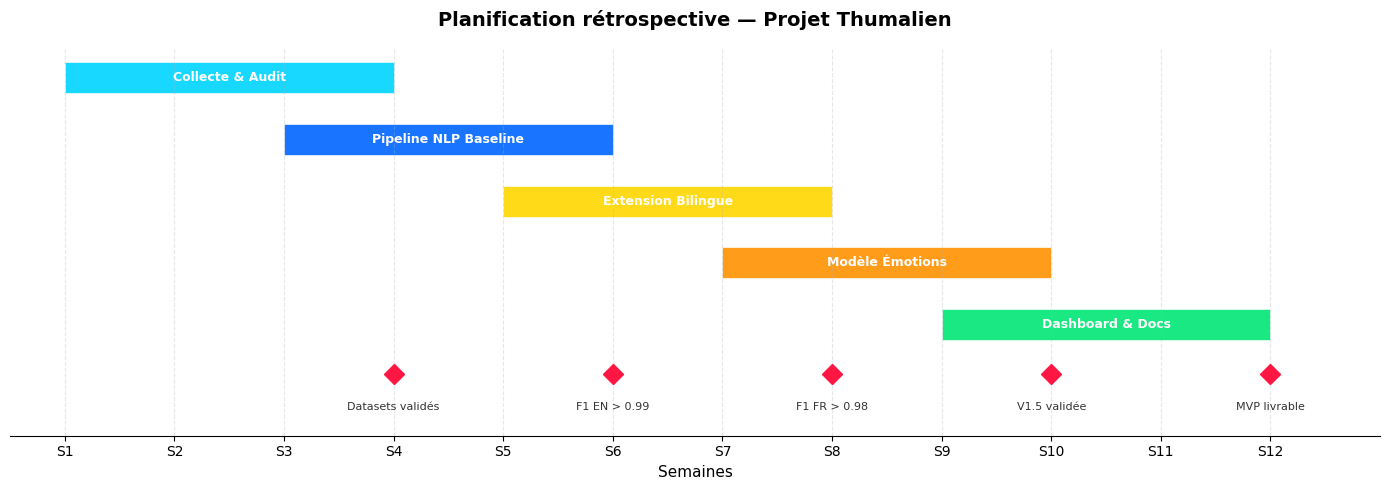

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# --- Données du Gantt ---
phases = [
    ('Dashboard & Docs', 9, 12, '#00E676'),
    ('Modèle Émotions', 7, 10, '#FF9100'),
    ('Extension Bilingue', 5, 8, '#FFD600'),
    ('Pipeline NLP Baseline', 3, 6, '#0066FF'),
    ('Collecte & Audit', 1, 4, '#00D4FF'),
]

milestones = [
    (4, 'Datasets validés'),
    (6, 'F1 EN > 0.99'),
    (8, 'F1 FR > 0.98'),
    (10, 'V1.5 validée'),
    (12, 'MVP livrable'),
]

fig, ax = plt.subplots(figsize=(14, 5))

# Barres horizontales
for i, (name, start, end, color) in enumerate(phases):
    ax.barh(i, end - start, left=start, height=0.5, color=color,
            edgecolor='white', linewidth=0.5, alpha=0.9, label=name)
    ax.text(start + (end - start) / 2, i, name,
            ha='center', va='center', fontsize=9, fontweight='600', color='white')

# Jalons (losanges rouges)
for sem, label in milestones:
    ax.plot(sem, -0.8, marker='D', color='#FF1744', markersize=10, zorder=5)
    ax.text(sem, -1.25, label, ha='center', va='top', fontsize=8, color='#333333')

# Mise en forme
ax.set_xlim(0.5, 13)
ax.set_ylim(-1.8, len(phases) - 0.5)
ax.set_xlabel('Semaines', fontsize=11, fontweight='500')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'S{i}' for i in range(1, 13)])
ax.set_yticks([])
ax.set_title('Planification rétrospective — Projet Thumalien',
             fontsize=14, fontweight='600', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_facecolor('#FFFFFF')
fig.patch.set_facecolor('#FFFFFF')

plt.tight_layout()

# Sauvegarder dans docs/
docs_dir = os.path.join('..', 'docs')
os.makedirs(docs_dir, exist_ok=True)
plt.savefig(os.path.join(docs_dir, 'gantt_planning.png'), dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("Gantt sauvegardé dans docs/gantt_planning.png")

plt.show()

### Risques rencontrés et mitigations

In [6]:
import pandas as pd

risques = pd.DataFrame({
    'Risque': [
        'Crash TensorFlow 2.20',
        'Biais Reuters (« Reuters » dans les textes)',
        'Déséquilibre classes FR (7 250 vs 44K EN)',
    ],
    'Impact': [
        'Bloquant — modèle émotions inutilisable',
        'F1 FR artificiellement gonflé',
        'F1 FR effondré (0.54 sans oversampling)',
    ],
    'Mitigation': [
        'Migration complète vers PyTorch 2.10',
        'Suppression du pattern Reuters dans DatasetCleaner',
        'Oversampling x3 des articles FR',
    ],
    'Résultat': [
        'F1 émotions 0.66, inférence stable',
        'F1 FR réel mesuré en ablation',
        'F1 FR 0.98',
    ],
})

display(risques.style.set_properties(**{
    'text-align': 'left',
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]},
]))

,Risque,Impact,Mitigation,Résultat
0,Crash TensorFlow 2.20,Bloquant — modèle émotions inutilisable,Migration complète vers PyTorch 2.10,"F1 émotions 0.66, inférence stable"
1,Biais Reuters (« Reuters » dans les textes),F1 FR artificiellement gonflé,Suppression du pattern Reuters dans DatasetCleaner,F1 FR réel mesuré en ablation
2,Déséquilibre classes FR (7 250 vs 44K EN),F1 FR effondré (0.54 sans oversampling),Oversampling x3 des articles FR,F1 FR 0.98
